# Chapter 8: Conditional Manatees — Interactions

## The Puzzle

**Terrain ruggedness** (mountains, ravines, difficult terrain) is generally bad for economic development — it raises transport costs, limits trade, hampers agriculture.

Except in Africa. There, ruggedness is *positively* associated with GDP.

**Why?** Historically, coastal and accessible regions of Africa were most exposed to the slave trade. Rugged terrain offered protection. The nations that avoided the slave trade retained more human capital and institutions, and they happen to be in rugged terrain.

**The statistical challenge**: a single regression line for all nations averages over this reversal and hides it. We need the *slope to vary by continent* — an **interaction**.

## Three Models

| Model | Formula | What it captures |
|-------|---------|------------------|
| m1 | α + β·rugged | No continent info — misses everything |
| m2 | α[cid] + β·rugged | Different intercepts, same slope |
| **m3** | **α[cid] + β[cid]·rugged** | **Different intercepts AND slopes — the interaction** |

`cid` = continent index (0 = non-Africa, 1 = Africa)

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import logsumexp
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))
from src.quap import quap

plt.style.use('default')
%matplotlib inline
np.random.seed(42)

print('✓ Imports loaded')

✓ Imports loaded


## Load and Prepare Data

In [2]:
url = 'https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/rugged.csv'
raw = pd.read_csv(url, sep=';')

# Keep only nations with GDP data
df = raw[['country', 'cont_africa', 'rugged', 'rgdppc_2000']].dropna().copy()
df = df.reset_index(drop=True)

# Scale variables (following the book)
# log_gdp_std: log GDP divided by the mean log GDP  → centred at 1.0
# rugged_std:  ruggedness divided by max             → range [0, 1]
df['log_gdp']     = np.log(df['rgdppc_2000'])
df['log_gdp_std'] = df['log_gdp'] / df['log_gdp'].mean()
df['rugged_std']  = df['rugged'] / df['rugged'].max()
df['cid']         = df['cont_africa'].astype(int)   # 0 = non-Africa, 1 = Africa

africa     = df[df['cid'] == 1]
non_africa = df[df['cid'] == 0]

print(f'Total nations with GDP: {len(df)}')
print(f'  Africa:     {len(africa)}')
print(f'  Non-Africa: {len(non_africa)}')
print(f'\nlog_gdp_std: mean={df["log_gdp_std"].mean():.3f}, sd={df["log_gdp_std"].std():.3f}')
print(f'rugged_std:  mean={df["rugged_std"].mean():.3f}, max={df["rugged_std"].max():.3f}')

Total nations with GDP: 170
  Africa:     49
  Non-Africa: 121

log_gdp_std: mean=1.000, sd=0.137
rugged_std:  mean=0.215, max=1.000


## Visualise the Puzzle

First, look at the raw data. Can you see the slope reversal?

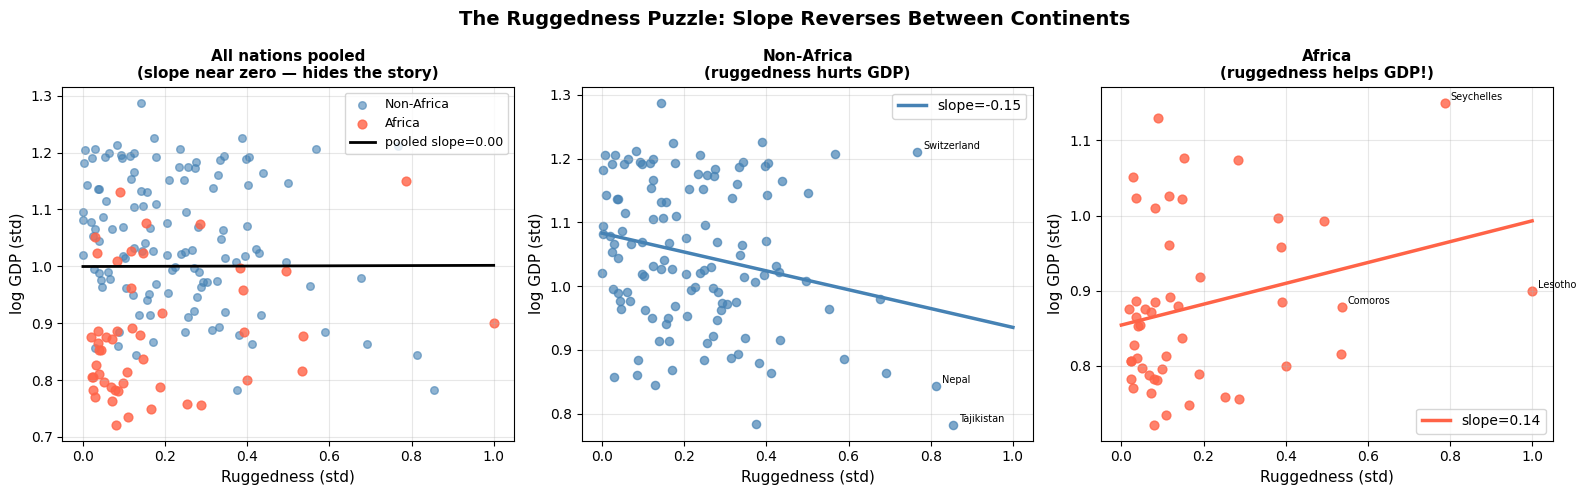

Pooled slope:     +0.002
Non-Africa slope: -0.148  (negative — ruggedness hurts)
Africa slope:     +0.139  (positive — ruggedness helps!)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: all nations pooled
ax = axes[0]
ax.scatter(non_africa['rugged_std'], non_africa['log_gdp_std'],
           s=30, alpha=0.6, color='steelblue', label='Non-Africa')
ax.scatter(africa['rugged_std'], africa['log_gdp_std'],
           s=40, alpha=0.8, color='tomato', label='Africa')
# Simple OLS trendline (pooled)
m, b = np.polyfit(df['rugged_std'], df['log_gdp_std'], 1)
xr = np.linspace(0, 1, 100)
ax.plot(xr, m*xr + b, 'k-', lw=2, label=f'pooled slope={m:.2f}')
ax.set_xlabel('Ruggedness (std)', fontsize=11)
ax.set_ylabel('log GDP (std)', fontsize=11)
ax.set_title('All nations pooled\n(slope near zero — hides the story)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: non-Africa
ax = axes[1]
ax.scatter(non_africa['rugged_std'], non_africa['log_gdp_std'],
           s=35, alpha=0.7, color='steelblue')
m2, b2 = np.polyfit(non_africa['rugged_std'], non_africa['log_gdp_std'], 1)
ax.plot(xr, m2*xr + b2, 'steelblue', lw=2.5, label=f'slope={m2:.2f}')
# Annotate a few countries
for _, row in non_africa.nlargest(3, 'rugged_std').iterrows():
    ax.annotate(row['country'], (row['rugged_std'], row['log_gdp_std']),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Ruggedness (std)', fontsize=11)
ax.set_ylabel('log GDP (std)', fontsize=11)
ax.set_title('Non-Africa\n(ruggedness hurts GDP)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel 3: Africa
ax = axes[2]
ax.scatter(africa['rugged_std'], africa['log_gdp_std'],
           s=40, alpha=0.8, color='tomato')
m3, b3 = np.polyfit(africa['rugged_std'], africa['log_gdp_std'], 1)
ax.plot(xr, m3*xr + b3, 'tomato', lw=2.5, label=f'slope={m3:.2f}')
for _, row in africa.nlargest(3, 'rugged_std').iterrows():
    ax.annotate(row['country'], (row['rugged_std'], row['log_gdp_std']),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Ruggedness (std)', fontsize=11)
ax.set_ylabel('log GDP (std)', fontsize=11)
ax.set_title('Africa\n(ruggedness helps GDP!)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('The Ruggedness Puzzle: Slope Reverses Between Continents',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Pooled slope:     {m:+.3f}')
print(f'Non-Africa slope: {m2:+.3f}  (negative — ruggedness hurts)')
print(f'Africa slope:     {m3:+.3f}  (positive — ruggedness helps!)')

## Prior Predictive Simulation

Before fitting, simulate regression lines from the prior to check that slopes are plausible.

**β ~ Normal(0, 1)**: too vague — many implied lines have slopes > 0.6, predicting GDP values outside the observable range.

**β ~ Normal(0, 0.3)**: much better — on a standardised scale, a slope of 0.3 means a full-range increase in ruggedness produces a 0.3 SD change in GDP, already a large effect.

The rule: *prior lines should be at least not embarrassing before we show the data.*

In [ ]:
rng_prior = np.random.default_rng(42)
n_lines   = 50
r_seq     = np.linspace(0, 1, 100)
r_bar_prior = df['rugged_std'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (beta_sigma, title, color) in zip(axes, [
    (1.0, 'β ~ Normal(0, 1)\n— too vague', 'tomato'),
    (0.3, 'β ~ Normal(0, 0.3)\n— weakly informative', 'steelblue'),
]):
    alpha_prior = rng_prior.normal(1, 0.1, n_lines)
    beta_prior  = rng_prior.normal(0, beta_sigma, n_lines)

    for a, b in zip(alpha_prior, beta_prior):
        ax.plot(r_seq, a + b * (r_seq - r_bar_prior),
                color=color, alpha=0.25, lw=1)

    # Mark the observed data range
    ax.axhline(df['log_gdp_std'].min(), color='gray', ls=':', lw=1, alpha=0.6)
    ax.axhline(df['log_gdp_std'].max(), color='gray', ls=':', lw=1, alpha=0.6)
    ax.fill_between(r_seq,
                    df['log_gdp_std'].min(), df['log_gdp_std'].max(),
                    alpha=0.06, color='green', label='observed data range')

    # Count implausible lines (> 20% of lines reach outside observed range)
    n_implausible = sum(
        (a + b * (r_seq - r_bar_prior)).max() > df['log_gdp_std'].max() * 1.1 or
        (a + b * (r_seq - r_bar_prior)).min() < df['log_gdp_std'].min() * 0.9
        for a, b in zip(alpha_prior, beta_prior)
    )

    ax.set_xlabel('Ruggedness (std)', fontsize=12)
    ax.set_ylabel('log GDP (std)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold', color=color)
    ax.set_ylim(0.4, 1.7)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.text(0.97, 0.05, f'{n_implausible}/{n_lines} lines\nleave observed range',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
            color=color, fontweight='bold')

plt.suptitle('Prior Predictive Check: Are Our Priors on β Reasonable?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Model 1: No Continent Information

$$\log(\text{GDP}_i) \sim \text{Normal}(\mu_i, \sigma)$$
$$\mu_i = \alpha + \beta \cdot (\text{rugged}_i - \bar{\text{rugged}})$$

**Priors**:
- `α ~ Normal(1, 0.1)` — log GDP std centred at 1 (by construction)
- `β ~ Normal(0, 0.3)` — weakly informative; a slope of 0.3 means 1 unit change in ruggedness → 0.3 SD change in GDP
- `σ ~ Exponential(1)`

In [4]:
y  = df['log_gdp_std'].values
r  = df['rugged_std'].values
cid = df['cid'].values
r_bar = r.mean()

def fit_m1(y, r):
    """No continent: single alpha and beta."""
    def nlp(params):
        alpha, beta, log_sigma = params
        sigma = np.exp(log_sigma)
        mu = alpha + beta * (r - r_bar)
        ll = np.sum(stats.norm.logpdf(y, mu, sigma))
        lp = (stats.norm.logpdf(alpha, 1, 0.1) +
              stats.norm.logpdf(beta, 0, 0.3) +
              stats.expon.logpdf(sigma, scale=1))
        return -(ll + lp + log_sigma)

    m = quap(nlp, [1.0, 0.0, np.log(0.1)], ['alpha', 'beta', 'log_sigma'])
    m.transform_param('log_sigma', 'sigma', np.exp)
    return m

m1 = fit_m1(y, r)
m1.summary()

✓ Registered transformation: log_sigma -> sigma
QUAP POSTERIOR APPROXIMATION
Converged: True
Time: 0.0169 seconds
Log posterior at MAP: 96.80

        mean    std  89%_lower  89%_upper
alpha 1.0000 0.0104     0.9833     1.0164
beta  0.0023 0.0552    -0.0866     0.0897
sigma 0.1371 0.0075     0.1258     0.1493


,mean,std,89%_lower,89%_upper
alpha,0.999979,0.010369,0.983328,1.016423
beta,0.002305,0.055161,-0.086569,0.089672
sigma,0.137125,0.007457,0.125759,0.149279


## Model 2: Different Intercepts per Continent

$$\mu_i = \alpha_{\text{cid}[i]} + \beta \cdot (\text{rugged}_i - \bar{\text{rugged}})$$

Africa has a lower average GDP (different intercept), but the *effect of ruggedness* is still assumed the same. This is a **main effect** of continent, not yet an interaction.

In [5]:
def fit_m2(y, r, cid):
    """Different intercepts per continent, shared slope."""
    def nlp(params):
        a0, a1, beta, log_sigma = params   # a0=non-Africa, a1=Africa
        sigma = np.exp(log_sigma)
        alpha = np.array([a0, a1])
        mu = alpha[cid] + beta * (r - r_bar)
        ll = np.sum(stats.norm.logpdf(y, mu, sigma))
        lp = (np.sum(stats.norm.logpdf([a0, a1], 1, 0.1)) +
              stats.norm.logpdf(beta, 0, 0.3) +
              stats.expon.logpdf(sigma, scale=1))
        return -(ll + lp + log_sigma)

    m = quap(nlp, [1.05, 0.9, 0.0, np.log(0.1)],
             ['alpha_0', 'alpha_1', 'beta', 'log_sigma'])
    m.transform_param('log_sigma', 'sigma', np.exp)
    return m

m2 = fit_m2(y, r, cid)
m2.summary()

⚠️  Warning: Optimization may not have converged!
   Message: Desired error not necessarily achieved due to precision loss.
✓ Registered transformation: log_sigma -> sigma
QUAP POSTERIOR APPROXIMATION
Converged: False
Time: 0.0277 seconds
Log posterior at MAP: 130.21

           mean    std  89%_lower  89%_upper
alpha_0  1.0491 0.0102     1.0328     1.0652
alpha_1  0.8803 0.0161     0.8546     0.9062
beta    -0.0460 0.0452    -0.1184     0.0255
sigma    0.1129 0.0062     0.1033     0.1229


,mean,std,89%_lower,89%_upper
alpha_0,1.049128,0.010184,1.032789,1.065157
alpha_1,0.880339,0.016111,0.854629,0.906169
beta,-0.046044,0.045245,-0.118416,0.025529
sigma,0.112928,0.006181,0.103340,0.122927


## Model 3: Full Interaction — Different Slopes AND Intercepts

$$\mu_i = \alpha_{\text{cid}[i]} + \beta_{\text{cid}[i]} \cdot (\text{rugged}_i - \bar{\text{rugged}})$$

Now each continent gets its own slope. This is the **index variable** approach to interactions — cleaner than multiplying a dummy variable by the predictor, and makes priors easier to specify independently for each group.

In [6]:
def fit_m3(y, r, cid):
    """Full interaction: separate alpha and beta per continent."""
    def nlp(params):
        a0, a1, b0, b1, log_sigma = params
        sigma = np.exp(log_sigma)
        alpha = np.array([a0, a1])
        beta  = np.array([b0, b1])
        mu = alpha[cid] + beta[cid] * (r - r_bar)
        ll = np.sum(stats.norm.logpdf(y, mu, sigma))
        lp = (np.sum(stats.norm.logpdf([a0, a1], 1, 0.1)) +
              np.sum(stats.norm.logpdf([b0, b1], 0, 0.3)) +
              stats.expon.logpdf(sigma, scale=1))
        return -(ll + lp + log_sigma)

    m = quap(nlp, [1.05, 0.9, -0.1, 0.1, np.log(0.1)],
             ['alpha_0', 'alpha_1', 'beta_0', 'beta_1', 'log_sigma'])
    m.transform_param('log_sigma', 'sigma', np.exp)
    return m

m3 = fit_m3(y, r, cid)
m3.summary()

coefs = m3.coef()
print(f"\nSlope for non-Africa: β₀ = {coefs['beta_0']:+.3f}  (negative — ruggedness hurts)")
print(f"Slope for Africa:     β₁ = {coefs['beta_1']:+.3f}  (positive — ruggedness helps!)")
print(f"\nThe interaction IS the reversal of slope between continents.")

✓ Registered transformation: log_sigma -> sigma
QUAP POSTERIOR APPROXIMATION
Converged: True
Time: 0.0264 seconds
Log posterior at MAP: 134.79

           mean    std  89%_lower  89%_upper
alpha_0  1.0506 0.0099     1.0347     1.0663
alpha_1  0.8866 0.0156     0.8618     0.9117
beta_0  -0.1431 0.0546    -0.2313    -0.0563
beta_1   0.1325 0.0755     0.0120     0.2528
sigma    0.1099 0.0060     0.1006     0.1199

Slope for non-Africa: β₀ = -0.143  (negative — ruggedness hurts)
Slope for Africa:     β₁ = +0.132  (positive — ruggedness helps!)

The interaction IS the reversal of slope between continents.


## Posterior Predictions: The Slope Reversal

The key visualisation — posterior regression lines from m3, split by continent.

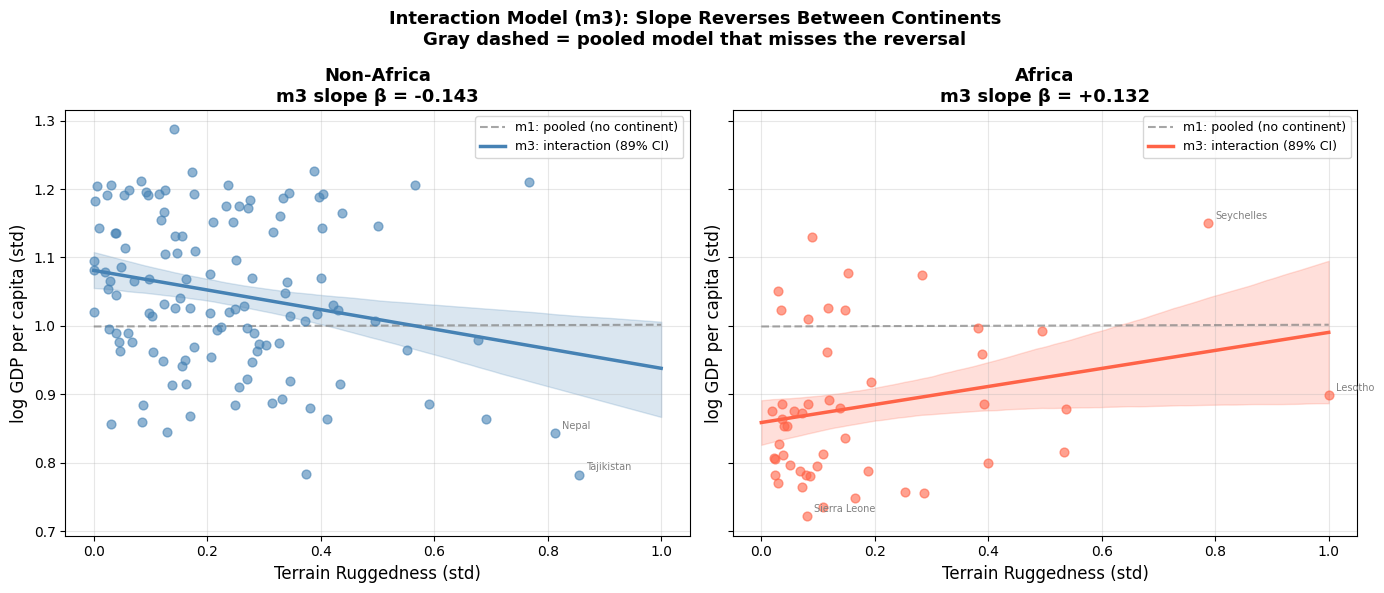

In [7]:
def posterior_lines(model, r_plot, cid_val, n_samples=2000):
    """Sample posterior regression lines for a given continent."""
    samples  = model.sample(n=n_samples, seed=42)
    alpha_s  = samples[f'alpha_{cid_val}'].values
    beta_s   = samples[f'beta_{cid_val}'].values
    mu_mat   = alpha_s[:, None] + beta_s[:, None] * (r_plot[None, :] - r_bar)  # (S, n_plot)
    return mu_mat.mean(axis=0), np.percentile(mu_mat, 5.5, axis=0), np.percentile(mu_mat, 94.5, axis=0)


r_plot = np.linspace(0, 1, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, (subset, cid_val, color, label) in zip(axes, [
        (non_africa, 0, 'steelblue', 'Non-Africa'),
        (africa,     1, 'tomato',    'Africa')
]):
    # Data points
    ax.scatter(subset['rugged_std'], subset['log_gdp_std'],
               s=40, alpha=0.6, color=color, zorder=3)

    # m1 (pooled — no continent)
    samp1   = m1.sample(n=2000, seed=42)
    mu1_mat = samp1['alpha'].values[:, None] + samp1['beta'].values[:, None] * (r_plot[None, :] - r_bar)
    mu1_mean = mu1_mat.mean(axis=0)
    ax.plot(r_plot, mu1_mean, 'gray', lw=1.5, ls='--', alpha=0.7, label='m1: pooled (no continent)')

    # m3 (interaction)
    mu3_mean, mu3_lo, mu3_hi = posterior_lines(m3, r_plot, cid_val)
    ax.fill_between(r_plot, mu3_lo, mu3_hi, alpha=0.2, color=color)
    ax.plot(r_plot, mu3_mean, color=color, lw=2.5, label='m3: interaction (89% CI)')

    # Annotate a few countries
    highlights = subset.nlargest(2, 'rugged_std').index.tolist() + \
                 subset.nsmallest(1, 'log_gdp_std').index.tolist()
    for idx in set(highlights):
        row = df.loc[idx]
        ax.annotate(row['country'], (row['rugged_std'], row['log_gdp_std']),
                    fontsize=7, xytext=(5, 3), textcoords='offset points', color='gray')

    coefs = m3.coef()
    slope = coefs[f'beta_{cid_val}']
    ax.set_xlabel('Terrain Ruggedness (std)', fontsize=12)
    ax.set_ylabel('log GDP per capita (std)', fontsize=12)
    ax.set_title(f'{label}\nm3 slope β = {slope:+.3f}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Interaction Model (m3): Slope Reverses Between Continents\n'
             'Gray dashed = pooled model that misses the reversal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## WAIC Model Comparison

In [8]:
def compute_waic(model, y, r, cid, n_samples=10_000):
    """Compute WAIC from quap posterior samples."""
    samples  = model.sample(n=n_samples, seed=42)
    n_obs    = len(y)
    param_names = [c for c in samples.columns if c not in ('log_sigma',)]

    # Build mu for each posterior sample
    # Handle all three model structures
    if 'beta_0' in samples.columns:          # m3: separate alpha and beta per continent
        a = np.stack([samples['alpha_0'].values, samples['alpha_1'].values], axis=1)  # (S,2)
        b = np.stack([samples['beta_0'].values,  samples['beta_1'].values],  axis=1)
        mu_mat = a[:, cid] + b[:, cid] * (r - r_bar)[None, :]                         # (S,N)
    elif 'alpha_0' in samples.columns:       # m2: separate alpha, shared beta
        a = np.stack([samples['alpha_0'].values, samples['alpha_1'].values], axis=1)
        mu_mat = a[:, cid] + samples['beta'].values[:, None] * (r - r_bar)[None, :]
    else:                                    # m1: pooled
        mu_mat = samples['alpha'].values[:, None] + samples['beta'].values[:, None] * (r - r_bar)[None, :]

    sigma_s  = samples['sigma'].values
    log_lik  = stats.norm.logpdf(y[None, :], mu_mat, sigma_s[:, None])   # (S, N)

    lppd_i   = logsumexp(log_lik, axis=0) - np.log(n_samples)
    p_waic_i = log_lik.var(axis=0)
    waic_i   = -2 * (lppd_i - p_waic_i)

    return dict(waic=waic_i.sum(), lppd=lppd_i.sum(),
                p_waic=p_waic_i.sum(), se=np.sqrt(n_obs * waic_i.var()))


w1 = compute_waic(m1, y, r, cid)
w2 = compute_waic(m2, y, r, cid)
w3 = compute_waic(m3, y, r, cid)

best = min(w1['waic'], w2['waic'], w3['waic'])
rows = []
for name, w in [('m1: pooled', w1), ('m2: continent intercept', w2), ('m3: full interaction', w3)]:
    rows.append(dict(Model=name, WAIC=round(w['waic'],1), lppd=round(w['lppd'],2),
                     p_WAIC=round(w['p_waic'],2), SE=round(w['se'],1),
                     dWAIC=round(w['waic']-best, 1)))

df_cmp = pd.DataFrame(rows)
print('WAIC model comparison:')
print('=' * 75)
print(df_cmp.to_string(index=False))
print('=' * 75)
print('\n✓ m3 (interaction) should have the lowest WAIC')

WAIC model comparison:
                  Model   WAIC   lppd  p_WAIC   SE  dWAIC
             m1: pooled -188.8  97.05    2.64 13.2   70.2
m2: continent intercept -252.2 130.35    4.27 15.2    6.9
   m3: full interaction -259.1 134.70    5.16 15.1    0.0

✓ m3 (interaction) should have the lowest WAIC


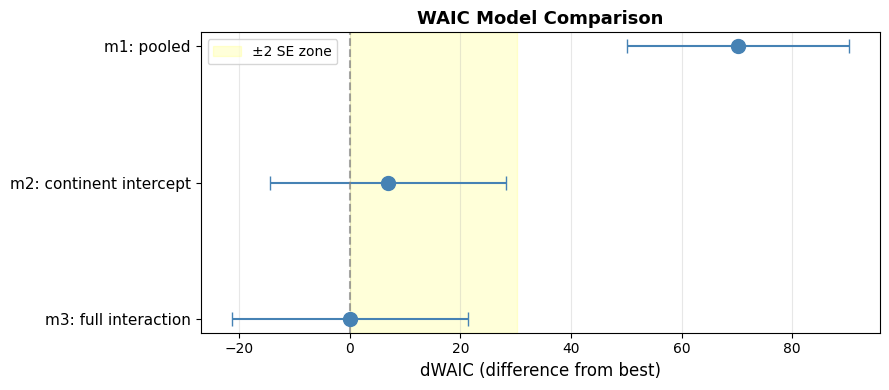

In [9]:
# dWAIC plot (McElreath style)
fig, ax = plt.subplots(figsize=(9, 4))

model_names = ['m1: pooled', 'm2: continent intercept', 'm3: full interaction']
waic_vals   = [w1['waic'], w2['waic'], w3['waic']]
se_vals     = [w1['se'],   w2['se'],   w3['se']]
best_se     = se_vals[np.argmin(waic_vals)]
dwaic       = [w - best for w in waic_vals]
dwaic_se    = [np.sqrt(se**2 + best_se**2) for se in se_vals]

order = np.argsort(dwaic)
ax.scatter([dwaic[i] for i in order], range(3), s=100, color='steelblue', zorder=3)
ax.errorbar([dwaic[i] for i in order], range(3),
            xerr=[dwaic_se[i] for i in order],
            fmt='none', color='steelblue', capsize=5, linewidth=1.5)
ax.set_yticks(range(3))
ax.set_yticklabels([model_names[i] for i in order], fontsize=11)
ax.axvline(0, color='gray', ls='--', alpha=0.7)
ax.axvspan(0, 2*best_se, color='yellow', alpha=0.15, label='±2 SE zone')
ax.set_xlabel('dWAIC (difference from best)', fontsize=12)
ax.set_title('WAIC Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Posterior Contrast: Is the Slope Difference Real?

We can directly ask: what is the posterior distribution of β₁ − β₀ (Africa slope minus non-Africa slope)?
If this is reliably positive, the interaction is real.

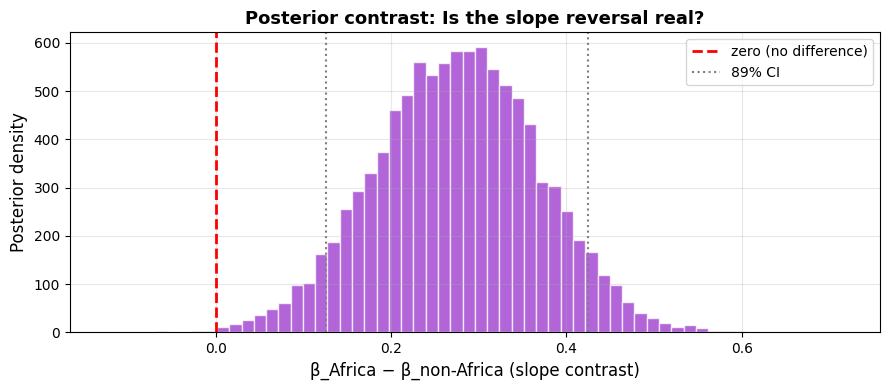

Mean contrast:  +0.276
89% CI:         [+0.126, +0.425]
P(β_Africa > β_non-Africa): 99.9%

✓ The entire 89% CI is above zero — strong evidence for slope reversal


In [10]:
samples_m3 = m3.sample(n=10_000, seed=42)
delta_beta = samples_m3['beta_1'].values - samples_m3['beta_0'].values   # Africa − non-Africa

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(delta_beta, bins=60, color='darkorchid', alpha=0.75, edgecolor='white')
ax.axvline(0, color='red', lw=2, ls='--', label='zero (no difference)')
ax.axvline(np.percentile(delta_beta, 5.5),  color='gray', lw=1.5, ls=':')
ax.axvline(np.percentile(delta_beta, 94.5), color='gray', lw=1.5, ls=':', label='89% CI')
ax.set_xlabel('β_Africa − β_non-Africa (slope contrast)', fontsize=12)
ax.set_ylabel('Posterior density', fontsize=12)
ax.set_title('Posterior contrast: Is the slope reversal real?', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

prob_positive = (delta_beta > 0).mean()
ci_lo, ci_hi  = np.percentile(delta_beta, [5.5, 94.5])
print(f'Mean contrast:  {delta_beta.mean():+.3f}')
print(f'89% CI:         [{ci_lo:+.3f}, {ci_hi:+.3f}]')
print(f'P(β_Africa > β_non-Africa): {prob_positive:.1%}')
print()
if ci_lo > 0:
    print('✓ The entire 89% CI is above zero — strong evidence for slope reversal')
else:
    print('⚠  CI crosses zero — slope reversal is uncertain at this sample size')

## Posterior Contrast: Intercepts (Africa vs Non-Africa)

The slope contrast tells us the *ruggedness effect* differs. The intercept contrast tells us: **how much richer is non-Africa on average, conditional on ruggedness?**

This is α_non-Africa − α_Africa, and should be reliably positive.

In [ ]:
delta_alpha = samples_m3['alpha_0'].values - samples_m3['alpha_1'].values  # non-Africa − Africa

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Panel 1: intercept contrast ───────────────────────────────────────────────
ax = axes[0]
ax.hist(delta_alpha, bins=60, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(0, color='red', lw=2, ls='--', label='zero (no difference)')
ax.axvline(np.percentile(delta_alpha, 5.5),  color='gray', lw=1.5, ls=':')
ax.axvline(np.percentile(delta_alpha, 94.5), color='gray', lw=1.5, ls=':', label='89% CI')
ax.set_xlabel('α_non-Africa − α_Africa (intercept contrast)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Intercept contrast\n(how much richer is non-Africa on average?)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 2: both contrasts side by side ─────────────────────────────────────
ax = axes[1]
contrasts  = [delta_alpha, delta_beta]
labels     = ['α: non-Africa − Africa\n(intercept)', 'β: Africa − non-Africa\n(slope)']
colors     = ['steelblue', 'darkorchid']
positions  = [1, 2]

for pos, contrast, label, color in zip(positions, contrasts, labels, colors):
    parts = ax.violinplot(contrast, positions=[pos], showmedians=True,
                          showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color); pc.set_alpha(0.6)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    # 89% CI
    lo, hi = np.percentile(contrast, [5.5, 94.5])
    ax.plot([pos, pos], [lo, hi], color=color, lw=4, alpha=0.8)

ax.axhline(0, color='red', ls='--', lw=1.5, alpha=0.7, label='zero')
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Posterior contrast value', fontsize=11)
ax.set_title('Both contrasts (violin + 89% CI)\n', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Posterior Contrasts: Intercept and Slope Differences',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ci_a = np.percentile(delta_alpha, [5.5, 94.5])
ci_b = np.percentile(delta_beta,  [5.5, 94.5])
print(f'Intercept contrast (non-Africa − Africa):')
print(f'  Mean = {delta_alpha.mean():+.3f},  89% CI = [{ci_a[0]:+.3f}, {ci_a[1]:+.3f}]')
print(f'  P(non-Africa richer) = {(delta_alpha > 0).mean():.1%}')
print()
print(f'Slope contrast (Africa − non-Africa):')
print(f'  Mean = {delta_beta.mean():+.3f},  89% CI = [{ci_b[0]:+.3f}, {ci_b[1]:+.3f}]')
print(f'  P(Africa slope > non-Africa slope) = {(delta_beta > 0).mean():.1%}')

## Key Insights

### 1. Pooling hides the story
The pooled model (m1) produces a slope near zero — ruggedness appears to have no effect. This is because the positive Africa effect and the negative non-Africa effect cancel each other out. **Averaging over heterogeneous groups destroys information.**

### 2. Main effects are not enough
Model m2 (different intercepts, shared slope) captures that Africa is poorer on average but still misses the slope reversal. Only m3 (full interaction) recovers the correct relationship in each group.

### 3. Index variable approach to interactions
Instead of adding a `β_A × cont_africa × rugged` interaction term, we fit **separate parameters per group** using an index variable. This is:
- Cleaner to read
- Easier to set independent priors for each group
- Equivalent mathematically to the interaction term formulation

### 4. The posterior contrast is the honest test
Rather than asking "is β significant?", we ask for the **posterior distribution of the difference** β_Africa − β_non-Africa. If this distribution is reliably far from zero, the interaction is real.

### 5. WAIC confirms m3
WAIC penalises the extra parameters in m3 but still prefers it — the slope reversal is real enough that the model earns its extra complexity.

---

**Part 2**: Continuous × continuous interactions — where both the predictor *and* the moderator are continuous variables.

## Section 8.2 — Symmetry of Interactions

The same interaction model can be read in two equivalent ways:

> **Reading A** *(what we've been doing)*: "The association between ruggedness and GDP is *conditional on continent* — positive in Africa, negative elsewhere."

> **Reading B** *(flip it)*: "The association between being in Africa and GDP is *conditional on ruggedness* — at low ruggedness, African nations are poorer; at high ruggedness, the gap shrinks or reverses."

These are not two different models. They are **the same model, described from two perspectives**. This is the symmetry of interactions: `X × Z` is indistinguishable from `Z × X`.

**Why does this matter?** It stops you from privileging one reading as "the causal story." The model is agnostic about which variable is the moderator and which is the predictor. That choice is yours, and it should come from domain knowledge and the DAG — not from the regression output.

In [ ]:

# ── Reading A: GDP ~ ruggedness, conditioned on continent ─────────────────────
# (same as before, condensed)
# ── Reading B: GDP ~ continent, conditioned on ruggedness ─────────────────────
# Choose 3 ruggedness levels
r_low  = np.percentile(r, 10)
r_med  = np.percentile(r, 50)
r_high = np.percentile(r, 90)
rugged_levels = {'Low (10th pct)': r_low, 'Median': r_med, 'High (90th pct)': r_high}

samples_m3 = m3.sample(n=10_000, seed=42)
a0s = samples_m3['alpha_0'].values   # non-Africa intercept
a1s = samples_m3['alpha_1'].values   # Africa intercept
b0s = samples_m3['beta_0'].values    # non-Africa slope
b1s = samples_m3['beta_1'].values    # Africa slope

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Panel A: GDP vs ruggedness (conditioned on continent) ─────────────────────
ax = axes[0]
r_plot = np.linspace(0, 1, 100)
for cid_val, color, label in [(0, 'steelblue', 'Non-Africa'), (1, 'tomato', 'Africa')]:
    subset = df[df['cid'] == cid_val]
    ax.scatter(subset['rugged_std'], subset['log_gdp_std'],
               s=25, alpha=0.45, color=color)
    a_s = a0s if cid_val == 0 else a1s
    b_s = b0s if cid_val == 0 else b1s
    mu_mat = a_s[:, None] + b_s[:, None] * (r_plot[None, :] - r_bar)
    mu_mean = mu_mat.mean(0)
    mu_lo   = np.percentile(mu_mat, 5.5,  axis=0)
    mu_hi   = np.percentile(mu_mat, 94.5, axis=0)
    ax.fill_between(r_plot, mu_lo, mu_hi, alpha=0.18, color=color)
    ax.plot(r_plot, mu_mean, color=color, lw=2.5, label=label)

ax.set_xlabel('Ruggedness (std)', fontsize=12)
ax.set_ylabel('log GDP (std)', fontsize=12)
ax.set_title('Reading A\nGDP ~ ruggedness | continent', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.text(0.97, 0.97, 'Moderator: Continent\nPredictor: Ruggedness',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='lightyellow', ec='gray', alpha=0.8))

# ── Panel B: GDP vs continent (Africa=1) at different ruggedness levels ────────
ax = axes[1]
x_pos   = np.array([0, 1])                   # 0 = non-Africa, 1 = Africa
offsets = [-0.12, 0, 0.12]                   # jitter for 3 ruggedness levels
palette = ['#2196F3', '#9C27B0', '#E91E63']  # blue, purple, pink

for offset, (rug_label, rug_val), color in zip(offsets, rugged_levels.items(), palette):
    # Posterior mean GDP for each continent at this ruggedness
    mu_nonaf = a0s + b0s * (rug_val - r_bar)  # (S,)
    mu_af    = a1s + b1s * (rug_val - r_bar)  # (S,)

    for cid_val, mu_s, xp in [(0, mu_nonaf, 0), (1, mu_af, 1)]:
        ax.errorbar(xp + offset, mu_s.mean(),
                    yerr=[[mu_s.mean() - np.percentile(mu_s, 5.5)],
                          [np.percentile(mu_s, 94.5) - mu_s.mean()]],
                    fmt='o', color=color, ms=8, capsize=5, lw=2,
                    label=rug_label if cid_val == 0 else '')

    # Connect non-Africa → Africa for each ruggedness level
    ax.plot([0 + offset, 1 + offset],
            [mu_nonaf.mean(), mu_af.mean()],
            color=color, lw=1.8, alpha=0.7, ls='--')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-Africa', 'Africa'], fontsize=12)
ax.set_ylabel('Posterior mean log GDP (std)', fontsize=12)
ax.set_title('Reading B\nGDP ~ continent | ruggedness level', fontsize=13, fontweight='bold')
ax.legend(title='Ruggedness level', fontsize=9, title_fontsize=9, loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
ax.text(0.03, 0.03,
        'At LOW ruggedness: non-Africa >> Africa\nAt HIGH ruggedness: gap shrinks/reverses',
        transform=ax.transAxes, ha='left', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', fc='lightyellow', ec='gray', alpha=0.8))

plt.suptitle('Symmetry of Interactions: Same Model, Two Perspectives\n'
             'Reading A and Reading B are mathematically identical',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Quantify the Africa penalty at each ruggedness level
print("Africa 'penalty' (non-Africa − Africa GDP) at different ruggedness levels:")
print(f"{'Ruggedness':<25} {'Mean contrast':>14}  {'89% CI':>20}")
print('-' * 62)
for rug_label, rug_val in rugged_levels.items():
    mu_nonaf = a0s + b0s * (rug_val - r_bar)
    mu_af    = a1s + b1s * (rug_val - r_bar)
    contrast = mu_nonaf - mu_af
    lo, hi   = np.percentile(contrast, [5.5, 94.5])
    print(f"{rug_label:<25} {contrast.mean():>+13.3f}  [{lo:+.3f}, {hi:+.3f}]")

print()
print("Interpretation: at high ruggedness, the Africa penalty shrinks.")
print("Same interaction — different reading.")
